#Enviroment setup

In [1]:
# possily needed to run twice
!pip install "numpy<2.0.0" "pandas<2.2.0" meteostat==1.6.7

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb
import holidays
import warnings
import shutil
from meteostat import Point, Daily

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = 'YOUR_PATH'

DATA_DIR = f'{DRIVE_PATH}/00_data/moratuwa_mc_2014-2018.csv'
RES_DIR = f'{DRIVE_PATH}/02_processed_data'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/EDA/Moratuwa'

# Data Load

In [4]:
print("=" * 100)
print("DATASET OVERVIEW")
print("=" * 100)

try:
    df = pd.read_csv(DATA_DIR)
    print(f"\nDataset loaded from DATA_PATH:")
    print(f"  Rows: {len(df):,} | Columns: {len(df.columns)}")
    print(f"  Columns: {list(df.columns)}")
except Exception as e:
    print(f"\nError loading dataset from DATA_PATH: {e}")

DATASET OVERVIEW

Dataset loaded from DATA_PATH:
  Rows: 6,691 | Columns: 4
  Columns: ['area', 'ticket_date', 'waste_type', 'net_weight_kg']


## Data Preview

In [5]:
df_raw = pd.read_csv(DATA_DIR)
df_raw['ticket_date'] = pd.to_datetime(df_raw['ticket_date'])
df_raw = df_raw[df_raw['ticket_date'] >= '2015-01-01']

print("=" * 100)
print(f"DATASET LOADED FROM: {DATA_DIR}")
print("=" * 100)
print(f"\nNumber of records: {len(df_raw):,}")
print(f"Areas: {df_raw['area'].unique()}")
print(f"Waste Types: {df_raw['waste_type'].unique()}")
print(f"\nData Sample:")
df_raw.head()

DATASET LOADED FROM: /content/drive/MyDrive/DP/00_data/moratuwa_mc_2014-2018.csv

Number of records: 6,623
Areas: ['Moratuwa MC']
Waste Types: ['MSW' 'Slaghter House Waste' 'Sorted Organic Waste' 'Industrial Waste'
 'Bulky Waste' 'Soil With Waste' 'Sanitary Waste' 'C&D Waste'
 'Indutrial Sludge Waste' 'Soil' 'Polythyne & Regiform' 'Wood Debris'
 'Special Waste' 'Saw Dust' 'Mesuring' 'Wood Trank']

Data Sample:


,area,ticket_date,waste_type,net_weight_kg
68,Moratuwa MC,2015-01-01,MSW,27250
69,Moratuwa MC,2015-01-01,Slaghter House Waste,2410
70,Moratuwa MC,2015-01-01,Sorted Organic Waste,33890
71,Moratuwa MC,2015-01-02,MSW,92880
72,Moratuwa MC,2015-01-02,Slaghter House Waste,1970


In [6]:
# aggregating all waste types into daily totals
daily = df_raw.groupby('ticket_date')['net_weight_kg'].sum().reset_index()
daily = df_raw.groupby('ticket_date')['net_weight_kg'].sum().reset_index()
daily.columns = ['date', 'total_kg']
daily = daily.sort_values('date').reset_index(drop=True)

# conversion to tonnes for readability
daily['total_tonnes'] = daily['total_kg'] / 1000

print(f"Number of Days: {len(daily)}")
print(f"Date Range: {daily['date'].min().date()} → {daily['date'].max().date()}")

Number of Days: 1308
Date Range: 2015-01-01 → 2018-12-11


In [7]:
# creating full date range
full_range = pd.date_range(daily['date'].min(), daily['date'].max(), freq='D')
daily = daily.set_index('date').reindex(full_range).rename_axis('date').reset_index()

# identification of missing days
missing_count = daily['total_kg'].isna().sum()
total_days = len(daily)

print(f"Total Date Range: {daily['date'].min().date()} to {daily['date'].max().date()}")
print(f"Total Days: {total_days}")
print(f"Missing Days to Impute: {missing_count} ({missing_count/total_days*100:.1f}%)")

Total Date Range: 2015-01-01 to 2018-12-11
Total Days: 1441
Missing Days to Impute: 133 (9.2%)


# Feature Engineering

## Holidays

In [8]:
def get_sri_lanka_holidays(start_year, end_year):
    """Fetch Sri Lankan public holidays including Poya days via 'holidays' library."""
    all_holidays = []
    sri_lanka_holidays = holidays.country_holidays('LK', years=range(start_year, end_year + 1))

    for date, name in sri_lanka_holidays.items():
        all_holidays.append({
            'date': pd.to_datetime(date),
            'holiday_name': name
        })

    return pd.DataFrame(all_holidays)

# fetching holidays
holidays_df = get_sri_lanka_holidays(daily['date'].dt.year.min(), daily['date'].dt.year.max())
holiday_dates = set(holidays_df['date'].values)

# creating calendar features
daily['year'] = daily['date'].dt.year
daily['month'] = daily['date'].dt.month
daily['day_of_week'] = daily['date'].dt.dayofweek
daily['day_of_year'] = daily['date'].dt.dayofyear
daily['week_of_year'] = daily['date'].dt.isocalendar().week.astype(int)
daily['is_weekend'] = (daily['day_of_week'] >= 5).astype(int)
daily['is_holiday'] = daily['date'].isin(holiday_dates).astype(int)
daily['is_after_weekend'] = (daily['day_of_week'] == 0).astype(int)
daily['is_after_holiday'] = daily['is_holiday'].shift(1).fillna(0).astype(int)

print(holidays_df)

         date                           holiday_name
0  2016-01-15                  Tamil Thai Pongal Day
1  2016-02-04                       Independence Day
2  2016-04-14             Sinhala and Tamil New Year
3  2016-04-13  Day Before Sinhala and Tamil New Year
4  2016-03-25                            Good Friday
..        ...                                    ...
95 2015-11-25                  Il Full Moon Poya Day
96 2015-12-24             Unduvap Full Moon Poya Day
97 2015-07-18                            Eid al-Fitr
98 2015-09-24                            Eid al-Adha
99 2015-07-01          Adhi Esala Full Moon Poya Day

[100 rows x 2 columns]


## Weather

In [9]:
# clearing Meteostat cache
cache_dir = os.path.expanduser('~/.meteostat/cache')

if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("Meteostat cache successfully wiped!")
else:
    print("No cache found.")

No cache found.


In [10]:
print("=" * 100)
print("Fetching historical weather data via Meteostat...")
print("=" * 100)

# fetching daily weather for Moratuwa (lat, lon, altitude)
location = Point(6.7731, 79.8824, 5)
start_date = daily['date'].min().to_pydatetime()
end_date = daily['date'].max().to_pydatetime()

weather_data = Daily(location, start_date, end_date)
weather_data = weather_data.fetch().reset_index()

# renaming the meteostat 'time' column to 'date'
weather_data = weather_data.rename(columns={'time': 'date'})

# selecting only relevant features: temperature, precipitation, wind speed
weather_features = weather_data[['date', 'tavg', 'prcp', 'wspd']]

# cleaning up missing weather data
weather_features = weather_features.ffill().bfill()

# merging weather into the dataset + doublecheck
daily = pd.merge(daily, weather_features, on='date', how='left')
daily[['tavg', 'prcp', 'wspd']] = daily[['tavg', 'prcp', 'wspd']].ffill().bfill()

print("\nWeather data successfully fetched and merged!")
print(daily[['date', 'tavg', 'prcp', 'wspd']].head())

Fetching historical weather data via Meteostat...

Weather data successfully fetched and merged!
        date  tavg  prcp  wspd
0 2015-01-01  27.0   6.9   6.4
1 2015-01-02  25.9   0.0   6.4
2 2015-01-03  26.1   0.0   6.4
3 2015-01-04  27.3   0.0   6.4
4 2015-01-05  27.8   1.5   6.4


# Missing Data & Outliers Handling

## Missing Values

VISUALIZING MISSING DATA GAPS AND OUTLIERS


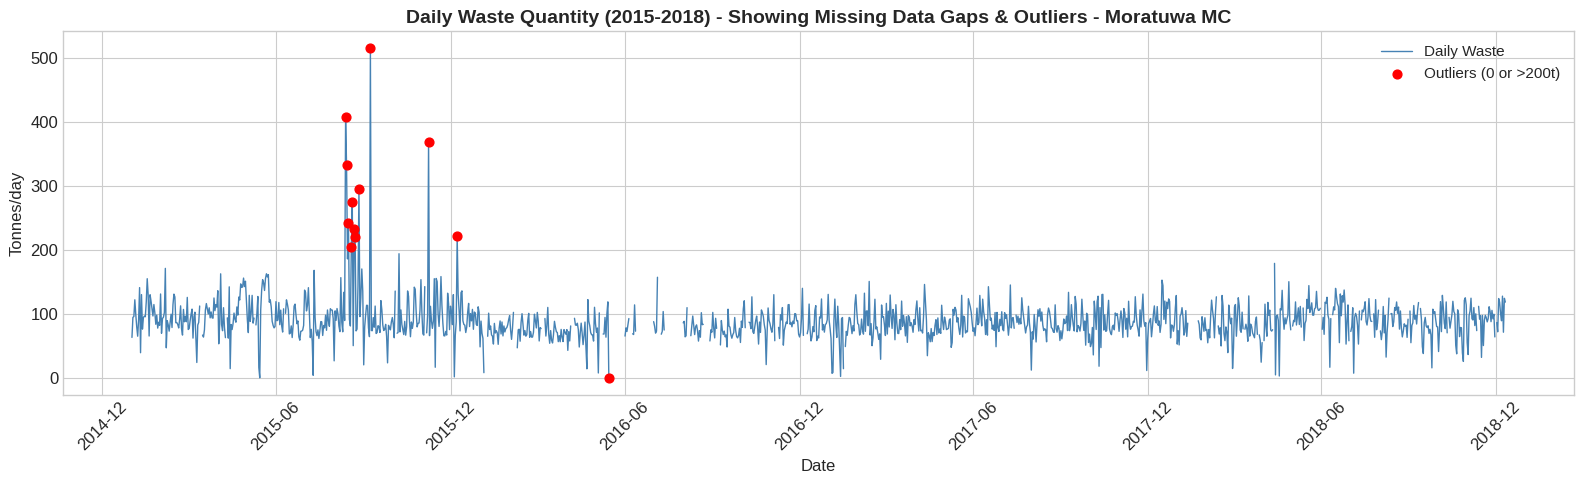

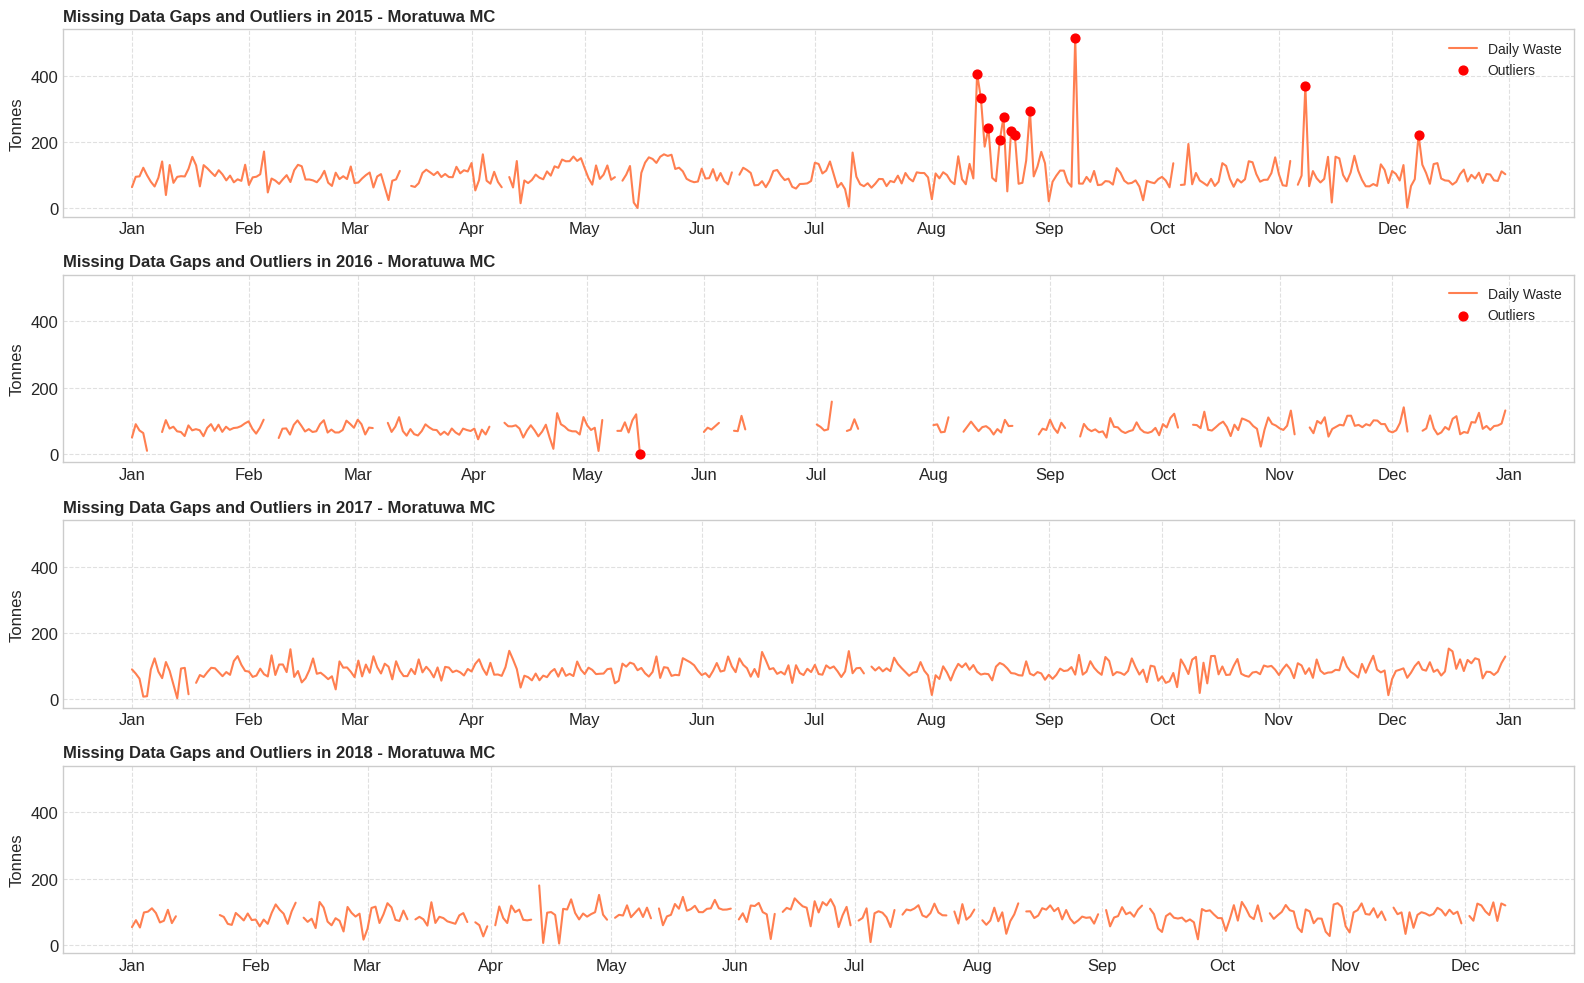

In [11]:
print("=" * 100)
print("VISUALIZING MISSING DATA GAPS AND OUTLIERS")
print("=" * 100)

# temporary column for plotting with NaNs preserved
daily['total_tonnes_with_nans'] = daily['total_kg'] / 1000

# identify outliers: zero values and extreme spikes above 200 tonnes - by visual observation
outlier_mask = (daily['total_tonnes_with_nans'] == 0) | (daily['total_tonnes_with_nans'] > 200)
outliers = daily[outlier_mask]


# --- Plot 401: Full timeline with gaps and outliers highlighted - Moratuwa MC ---
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily['date'], daily['total_tonnes_with_nans'], color='steelblue', linewidth=1, label='Daily Waste')

if not outliers.empty:
    ax.scatter(outliers['date'], outliers['total_tonnes_with_nans'], color='red', s=40, zorder=5, label='Outliers (0 or >200t)')

ax.set_title('Daily Waste Quantity (2015-2018) - Showing Missing Data Gaps & Outliers - Moratuwa MC', fontsize=14, fontweight='bold')
ax.set_ylabel('Tonnes/day')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, '401_base_data_full_timeline_mo.png'), dpi=150, bbox_inches='tight')
plt.show()


# --- Plot 402: Year-by-year breakdown for seasonal gap analysis - Moratuwa MC ---
years = sorted(daily['year'].dropna().unique().astype(int))
fig, axes = plt.subplots(len(years), 1, figsize=(16, 2.5 * len(years)), sharey=True)

for i, year in enumerate(years):
    year_data = daily[daily['year'] == year]
    year_outliers = outliers[outliers['year'] == year]

    axes[i].plot(year_data['date'], year_data['total_tonnes_with_nans'], color='coral', linewidth=1.5, label='Daily Waste')

    if not year_outliers.empty:
        axes[i].scatter(year_outliers['date'], year_outliers['total_tonnes_with_nans'], color='red', s=40, zorder=5, label='Outliers')
        axes[i].legend(loc='upper right', fontsize=10)

    axes[i].set_title(f'Missing Data Gaps and Outliers in {year} - Moratuwa MC', fontsize=12, fontweight='bold', loc='left')
    axes[i].set_ylabel('Tonnes')

    axes[i].xaxis.set_major_locator(mdates.MonthLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, '402_base_data_by_year_mo.png'), dpi=150, bbox_inches='tight')
plt.show()


# droping the temporary column
daily = daily.drop(columns=['total_tonnes_with_nans'])

## Outliers

In [12]:
print("=" * 100)
print("REMOVING OUTLIERS BEFORE IMPUTATION")
print("=" * 100)

# defining records for imputation
temp_tonnes = daily['total_kg'] / 1000

zero_mask = temp_tonnes == 0
high_mask = temp_tonnes > 200

outlier_mask = zero_mask | high_mask
outliers_to_remove = daily[outlier_mask]

print(f"Found {len(outliers_to_remove)} outliers to replace with XGBoost predictions:\n")


# displating each outlier with its 30-day neighborhood context
if not outliers_to_remove.empty:

    print(f"{'Date':<12} | {'Outlier (t)':<13} | {'30-Day Avg (t)':<14} | {'30-Day Median (t)'}")
    print("-" * 65)

    for idx, row in outliers_to_remove.iterrows():
        outlier_date = row['date']
        outlier_val = row['total_kg'] / 1000

        window_start = outlier_date - pd.Timedelta(days=15)
        window_end = outlier_date + pd.Timedelta(days=15)

        window_data = daily[(daily['date'] >= window_start) &
                            (daily['date'] <= window_end) &
                            (daily['date'] != outlier_date)]

        window_mean = (window_data['total_kg'] / 1000).mean()
        window_median = (window_data['total_kg'] / 1000).median()

        print(f"{outlier_date.strftime('%Y-%m-%d'):<12} | {outlier_val:>10.1f}    | {window_mean:>10.1f}       | {window_median:>10.1f}")


# setting outliers to NaN
daily.loc[outlier_mask, 'total_kg'] = np.nan
daily['total_tonnes'] = daily['total_kg'] / 1000

REMOVING OUTLIERS BEFORE IMPUTATION
Found 12 outliers to replace with XGBoost predictions:

Date         | Outlier (t)   | 30-Day Avg (t) | 30-Day Median (t)
-----------------------------------------------------------------
2015-08-13   |      407.4    |      134.5       |      102.7
2015-08-14   |      333.1    |      137.6       |      102.7
2015-08-16   |      242.2    |      144.2       |      106.8
2015-08-19   |      205.1    |      144.7       |      104.5
2015-08-20   |      275.3    |      142.5       |      107.0
2015-08-22   |      233.0    |      144.3       |      113.6
2015-08-23   |      220.6    |      144.4       |      113.6
2015-08-27   |      294.9    |      152.2       |      105.9
2015-09-08   |      515.4    |       98.6       |       81.2
2015-11-08   |      368.6    |      103.6       |      100.2
2015-12-08   |      221.6    |       91.5       |       86.6
2016-05-15   |        0.0    |       81.0       |       81.8


## XGB Imputation

XGBOOST IMPUTATION & EVALUATION
--- MODEL EVALUATION METRICS (20% TEST SET) ---
MAE  (Mean Absolute Error):        16.94 Tonnes
RMSE (Root Mean Squared Error):    22.29 Tonnes
MAPE (Mean Absolute Percentage):   24.32 %
--------------------------------------------------


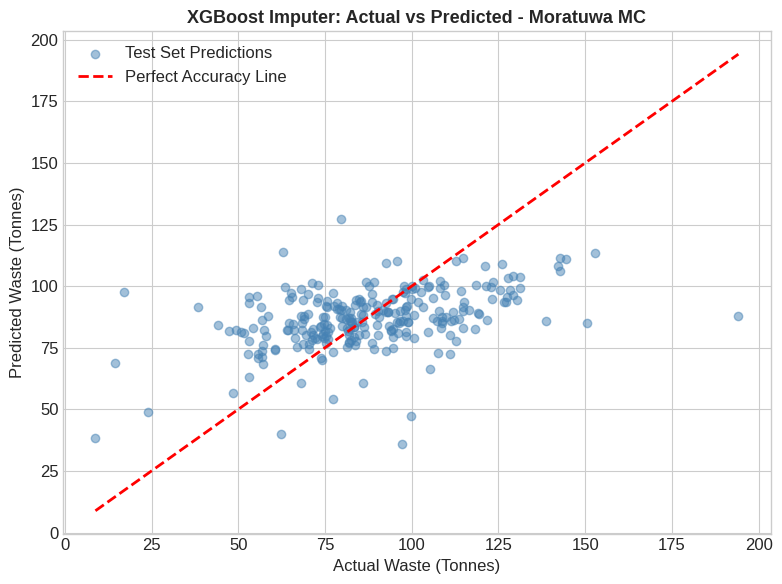


Retraining model on 100% of known data to maximize accuracy...
Successfully imputed 145 missing/outlier days!


In [13]:
print("=" * 100)
print("XGBOOST IMPUTATION & EVALUATION")
print("=" * 100)

# flagging rows that will be imputed
daily['is_imputed'] = daily['total_kg'].isna()

# features available before imputation
impute_features = [
    'year', 'month', 'day_of_week', 'day_of_year',
    'week_of_year', 'is_weekend', 'is_holiday',
    'tavg', 'prcp', 'wspd',
    'is_after_weekend', 'is_after_holiday'
]
target = 'total_kg'

known_data = daily[daily[target].notna()]
missing_data = daily[daily[target].isna()]

X = known_data[impute_features]
y = known_data[target]


# --- Phase 1: Evaluate imputer accuracy on 80/20 split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

eval_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    objective='reg:squarederror'
)
eval_model.fit(X_train, y_train)
y_pred = eval_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("--- MODEL EVALUATION METRICS (20% TEST SET) ---")
print(f"MAE  (Mean Absolute Error):        {mae/1000:.2f} Tonnes")
print(f"RMSE (Root Mean Squared Error):    {rmse/1000:.2f} Tonnes")
print(f"MAPE (Mean Absolute Percentage):   {mape:.2f} %")
print("-" * 50)


# --- Plot 403: Year-by-year breakdown for seasonal gap analysis - Moratuwa MC ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test / 1000, y_pred / 1000, alpha=0.5, color='steelblue', label='Test Set Predictions')

min_val = min(y_test.min(), y_pred.min()) / 1000
max_val = max(y_test.max(), y_pred.max()) / 1000
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Accuracy Line')

ax.set_xlabel('Actual Waste (Tonnes)')
ax.set_ylabel('Predicted Waste (Tonnes)')
ax.set_title('XGBoost Imputer: Actual vs Predicted - Moratuwa MC', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, '403_imputer_evaluation_mo.png'), dpi=150, bbox_inches='tight')
plt.show()


# --- Phase 2: Retrain on all known data and fill gaps ---
print("\nRetraining model on 100% of known data to maximize accuracy...")
final_imputer = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    objective='reg:squarederror'
)

final_imputer.fit(X, y)

predicted_missing = final_imputer.predict(missing_data[impute_features])
daily.loc[daily[target].isna(), target] = predicted_missing
daily['total_tonnes'] = daily['total_kg'] / 1000

print(f"Successfully imputed {len(predicted_missing)} missing/outlier days!")

VISUALIZING IMPUTATION (Line Chart with Highlighted Gaps)


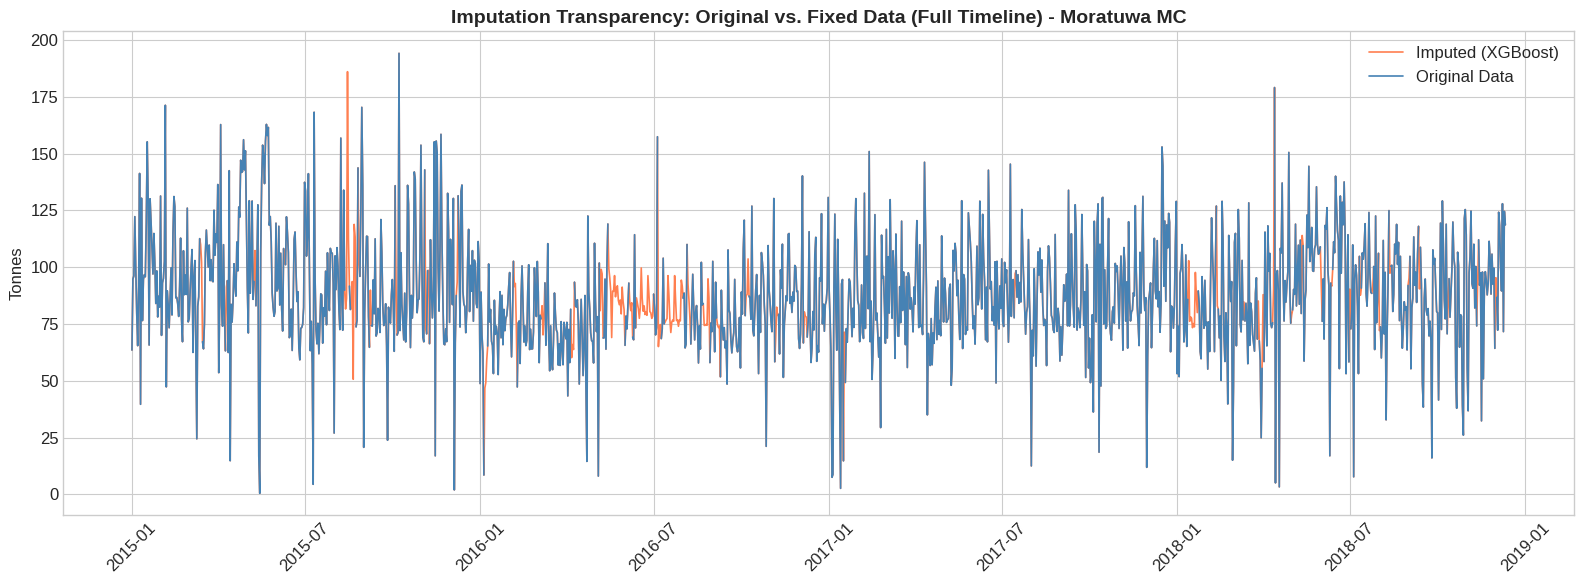

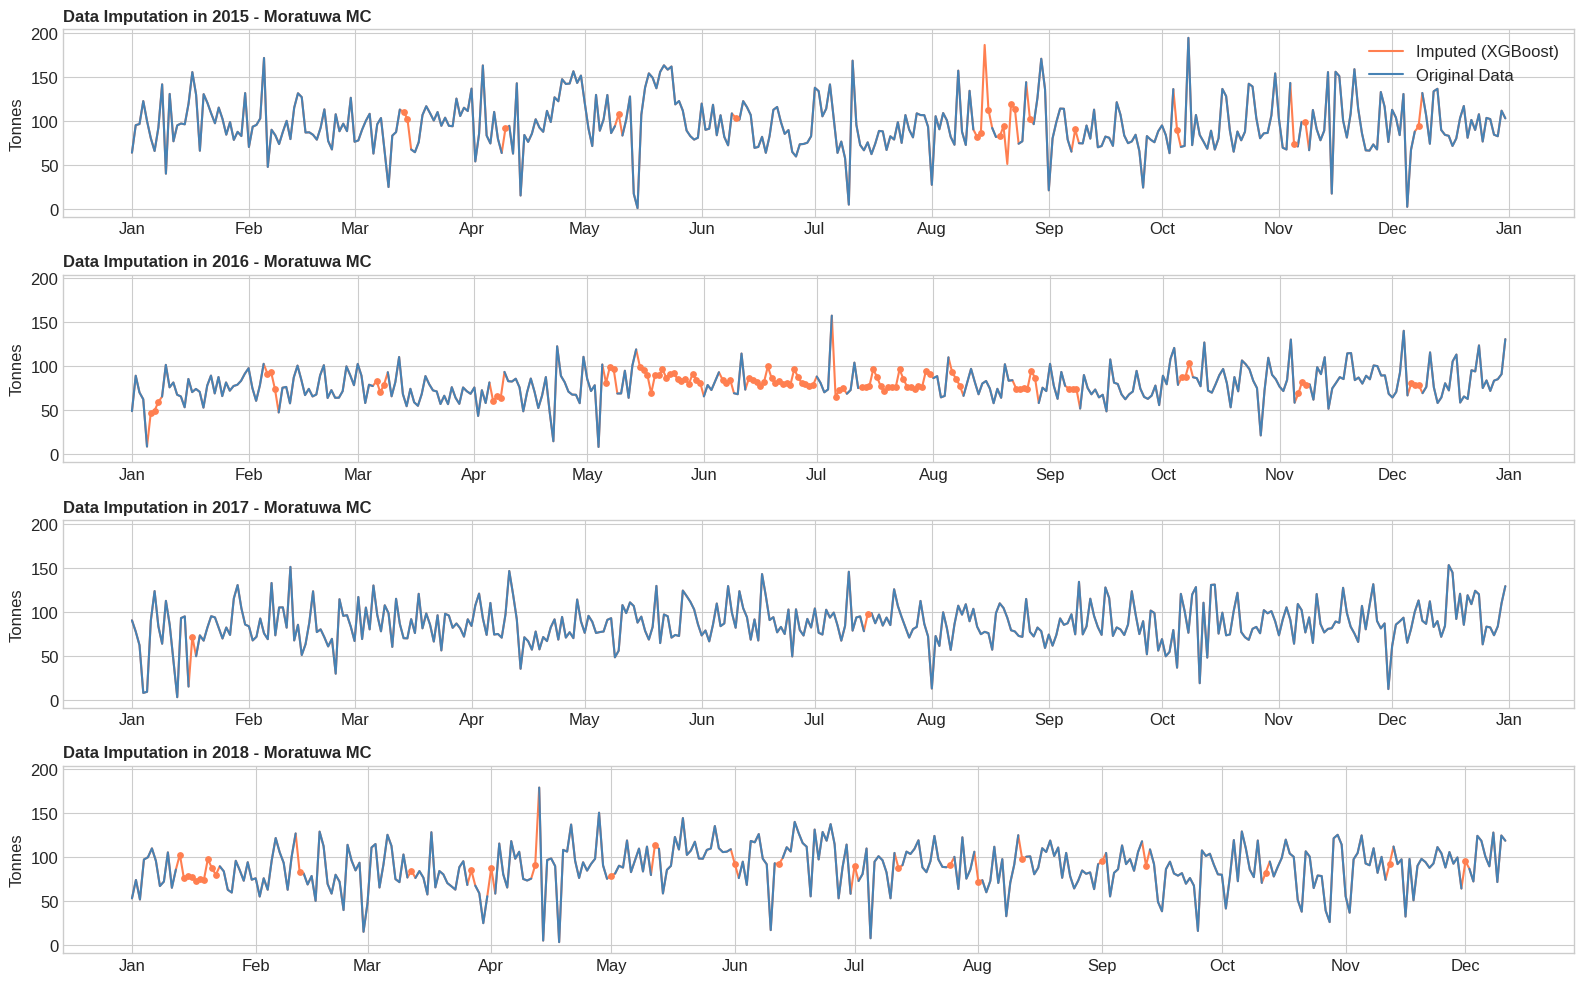

In [14]:
print("=" * 100)
print("VISUALIZING IMPUTATION (Line Chart with Highlighted Gaps)")
print("=" * 100)

# separating original data from imputed values for visual comparison
daily['original_only'] = daily['total_tonnes'].copy()
daily.loc[daily['is_imputed'] == True, 'original_only'] = np.nan


# --- Plot 404: Full timeline showing where imputation filled gaps - Moratuwa MC ---
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(daily['date'], daily['total_tonnes'], color='coral',
        linewidth=1.2, label='Imputed (XGBoost)', zorder=1)

ax.plot(daily['date'], daily['original_only'], color='steelblue',
        linewidth=1.2, label='Original Data', zorder=2)

ax.set_title('Imputation Transparency: Original vs. Fixed Data (Full Timeline) - Moratuwa MC', fontsize=14, fontweight='bold')
ax.set_ylabel('Tonnes')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, '404_imputed_data_full_timeline_mo.png'), dpi=150)
plt.show()


# --- Plot 405: Year-by-year with imputed points highlighted - Moratuwa MC ---
years = sorted(daily['year'].dropna().unique().astype(int))
fig, axes = plt.subplots(len(years), 1, figsize=(16, 2.5 * len(years)), sharey=True)

for i, year in enumerate(years):
    yr_data = daily[daily['year'] == year]

    axes[i].plot(yr_data['date'], yr_data['total_tonnes'], color='coral', linewidth=1.5, zorder=1)
    axes[i].plot(yr_data['date'], yr_data['original_only'], color='steelblue', linewidth=1.5, zorder=2)

    imp_pts = yr_data[yr_data['is_imputed'] == True]
    axes[i].scatter(imp_pts['date'], imp_pts['total_tonnes'], color='coral', s=15, zorder=3)

    axes[i].set_title(f'Data Imputation in {year} - Moratuwa MC', fontsize=12, fontweight='bold', loc='left')
    axes[i].set_ylabel('Tonnes')
    axes[i].xaxis.set_major_locator(mdates.MonthLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    if i == 0:
        axes[i].legend(['Imputed (XGBoost)', 'Original Data'], loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, '405_imputed_by_year_mo.png'), dpi=150)
plt.show()

# Advanced Feature Engineering

In [15]:
print("=" * 100)
print("ENRICHING DATASET: ROLLING, CYCLICAL, AND LAG FEATURES")
print("=" * 100)

# rolling window statistics
daily['rolling_7_mean'] = daily['total_tonnes'].rolling(7, min_periods=1).mean()
daily['rolling_7_std']  = daily['total_tonnes'].rolling(7, min_periods=1).std()
daily['rolling_30_mean'] = daily['total_tonnes'].rolling(30, min_periods=1).mean()

# cyclical encoding for periodic features (month, day of week)
daily['month_sin'] = np.sin(2 * np.pi * daily['month'] / 12)
daily['month_cos'] = np.cos(2 * np.pi * daily['month'] / 12)
daily['dow_sin']   = np.sin(2 * np.pi * daily['day_of_week'] / 7)
daily['dow_cos']   = np.cos(2 * np.pi * daily['day_of_week'] / 7)

# lag features
for lag in [1, 2, 3, 7, 14, 30]:
    daily[f'lag_{lag}'] = daily['total_tonnes'].shift(lag)

print(f"Features created. Final shape: {daily.shape}")

ENRICHING DATASET: ROLLING, CYCLICAL, AND LAG FEATURES
Features created. Final shape: (1441, 30)


# Explanatory Data Analysis

VISUALIZING DAILY WASTE TIMESERIES


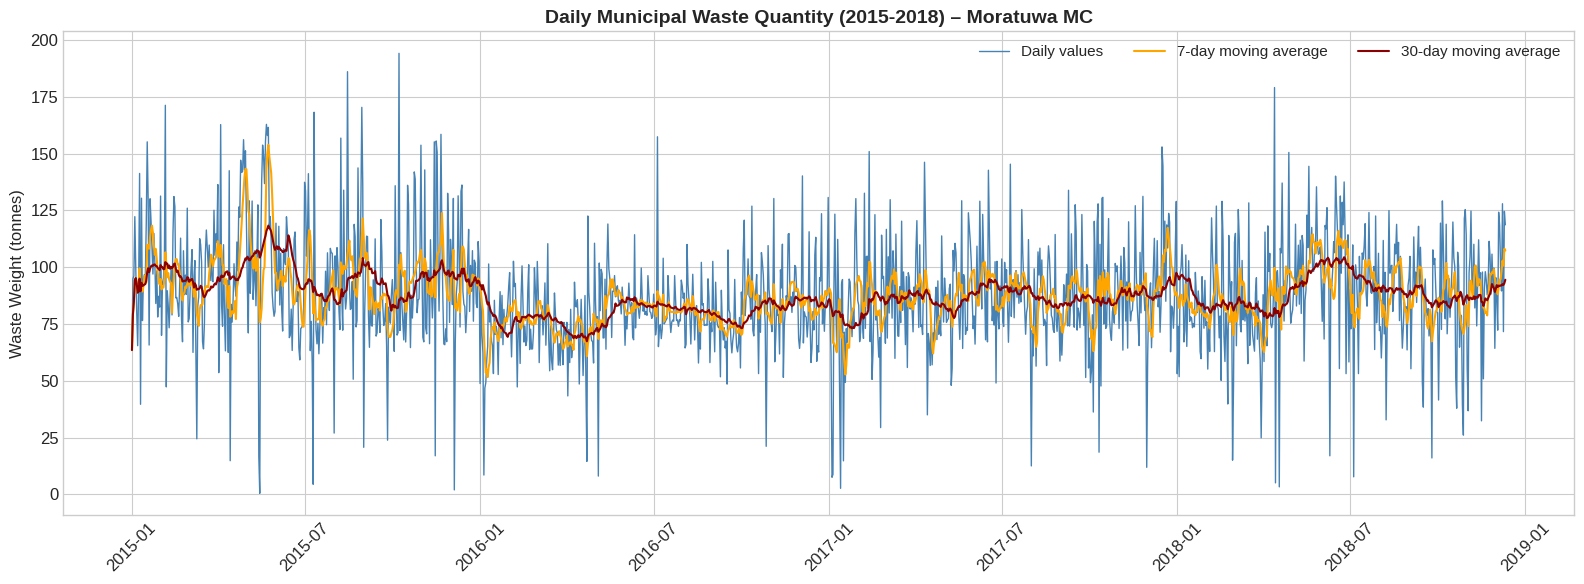

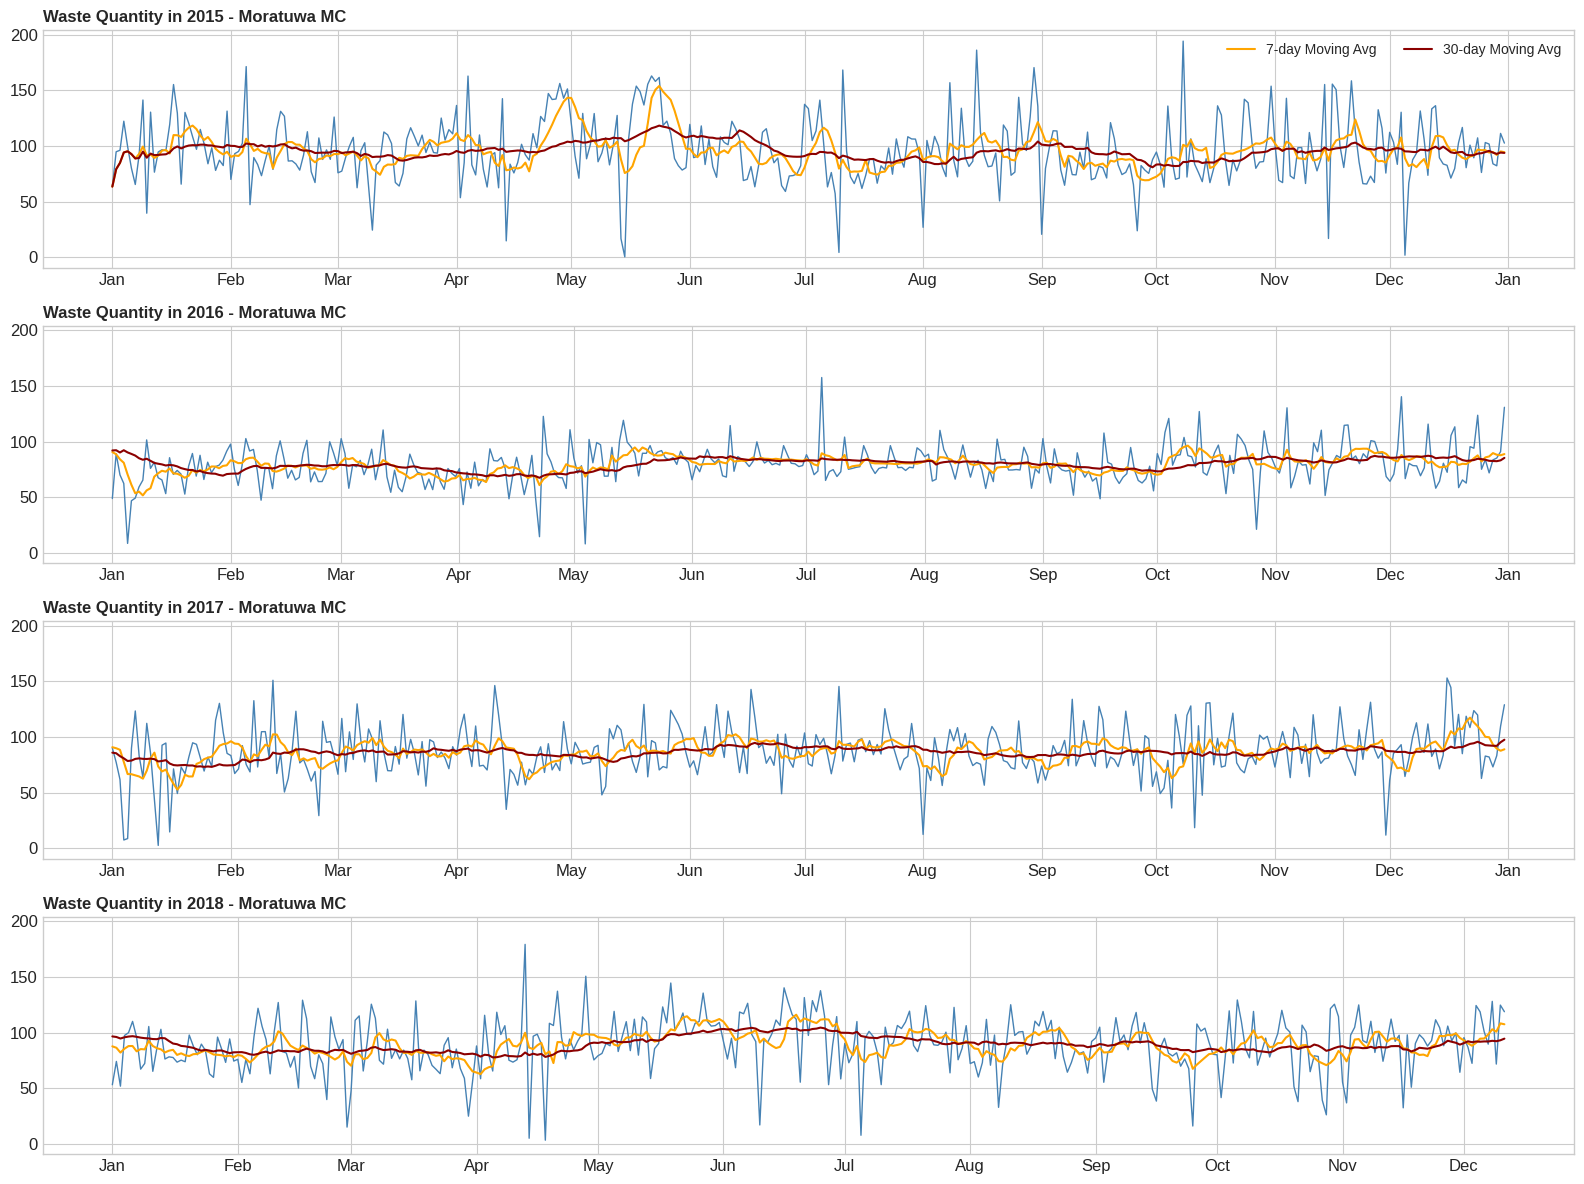

In [16]:
print("=" * 100)
print("VISUALIZING DAILY WASTE TIMESERIES")
print("=" * 100)

# --- Plot 411: Full timeline with rolling averages - Moratuwa MC ---
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(daily['date'], daily['total_tonnes'], linewidth=1, color='steelblue', label='Daily values')

ax.plot(daily['date'], daily['rolling_7_mean'], linewidth=1.5, color='orange', label='7-day moving average')
ax.plot(daily['date'], daily['rolling_30_mean'], linewidth=1.5, color='darkred', label='30-day moving average')

ax.set_title('Daily Municipal Waste Quantity (2015-2018) – Moratuwa MC', fontsize=14, fontweight='bold')
ax.set_ylabel('Waste Weight (tonnes)')
ax.legend(fontsize=11, loc='upper right', ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, '411_timeseries_full_timeline_mo.png'), dpi=150, bbox_inches='tight')
plt.show()


# --- Plot 412: Year-by-year with rolling averages - Moratuwa MC ---
years = sorted(daily['year'].dropna().unique().astype(int))
fig, axes = plt.subplots(len(years), 1, figsize=(16, 3 * len(years)), sharey=True)

for i, year in enumerate(years):
    year_data = daily[daily['year'] == year]

    axes[i].plot(year_data['date'], year_data['total_tonnes'], color='steelblue', linewidth=1)

    axes[i].plot(year_data['date'], year_data['rolling_7_mean'], color='orange', linewidth=1.5, label='7-day Moving Avg')
    axes[i].plot(year_data['date'], year_data['rolling_30_mean'], color='darkred', linewidth=1.5, label='30-day Moving Avg')

    axes[i].set_title(f'Waste Quantity in {year} - Moratuwa MC', fontsize=12, fontweight='bold', loc='left')
    axes[i].xaxis.set_major_locator(mdates.MonthLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    if i == 0:
        axes[i].legend(loc='upper right', fontsize=10, ncol=3)

plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, '412_timeseries_by_year_mo.png'), dpi=150, bbox_inches='tight')
plt.show()

VISUALIZING WASTE DISTRIBUTION


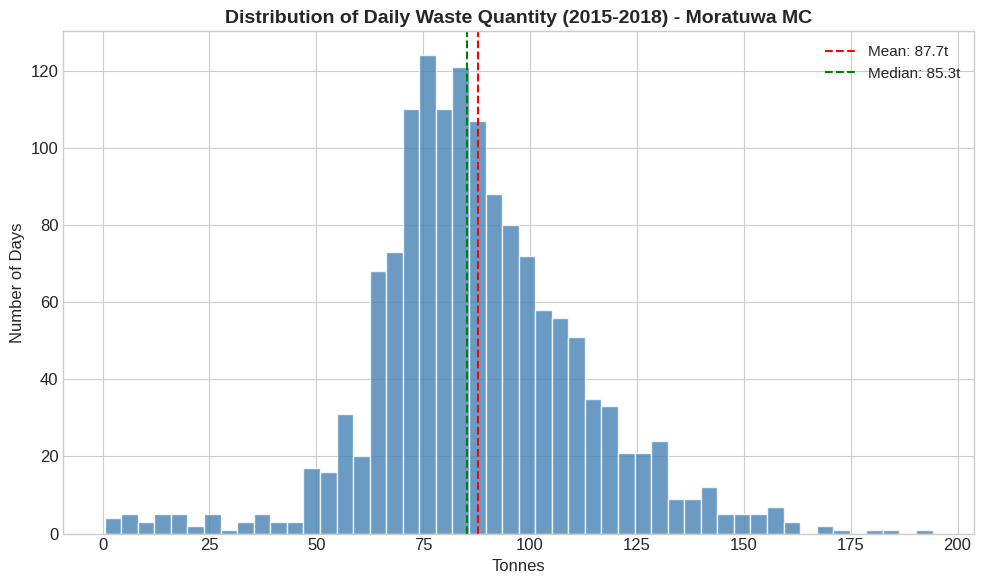

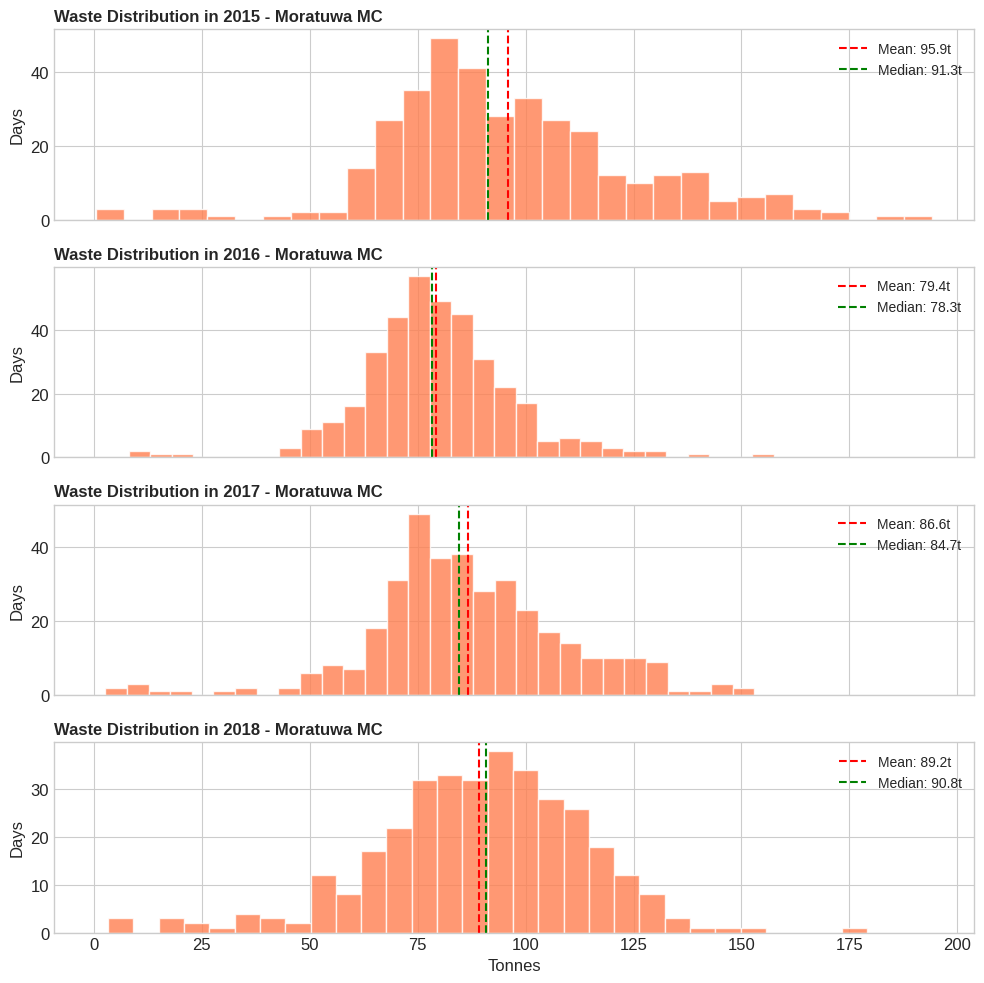

In [17]:
print("=" * 100)
print("VISUALIZING WASTE DISTRIBUTION")
print("=" * 100)


# --- Plot 421: Overall histogram with mean/median - Moratuwa MC ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(daily['total_tonnes'], bins=50, color='steelblue',
        edgecolor='white', alpha=0.8)

ax.axvline(daily['total_tonnes'].mean(), color='red', linestyle='--',
           label=f'Mean: {daily["total_tonnes"].mean():.1f}t')
ax.axvline(daily['total_tonnes'].median(), color='green', linestyle='--',
           label=f'Median: {daily["total_tonnes"].median():.1f}t')

ax.set_title('Distribution of Daily Waste Quantity (2015-2018) - Moratuwa MC',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tonnes')
ax.set_ylabel('Number of Days')
ax.legend(fontsize=11)
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '421_waste_distribution_full_timeline_mo.png'), dpi=150, bbox_inches='tight')
plt.show()


# --- Plot 422: Year-by-year comparison - Moratuwa MC ---
years = sorted(daily['year'].dropna().unique().astype(int))
fig, axes = plt.subplots(len(years), 1, figsize=(10, 2.5 * len(years)), sharex=True)

for i, year in enumerate(years):
    year_data = daily[daily['year'] == year]['total_tonnes'].dropna()

    axes[i].hist(year_data, bins=30, color='coral', edgecolor='white', alpha=0.8)

    y_mean = year_data.mean()
    y_median = year_data.median()

    axes[i].axvline(y_mean, color='red', linestyle='--', label=f'Mean: {y_mean:.1f}t')
    axes[i].axvline(y_median, color='green', linestyle='--', label=f'Median: {y_median:.1f}t')

    axes[i].set_title(f'Waste Distribution in {year} - Moratuwa MC', fontsize=12, fontweight='bold', loc='left')
    axes[i].set_ylabel('Days')
    axes[i].legend(loc='upper right', fontsize=10)

axes[-1].set_xlabel('Tonnes')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '422_waste_distribution_by_year_mo.png'), dpi=150, bbox_inches='tight')
plt.show()

VISUALIZING LONG-TERM TRENDS (Monthly Sums)


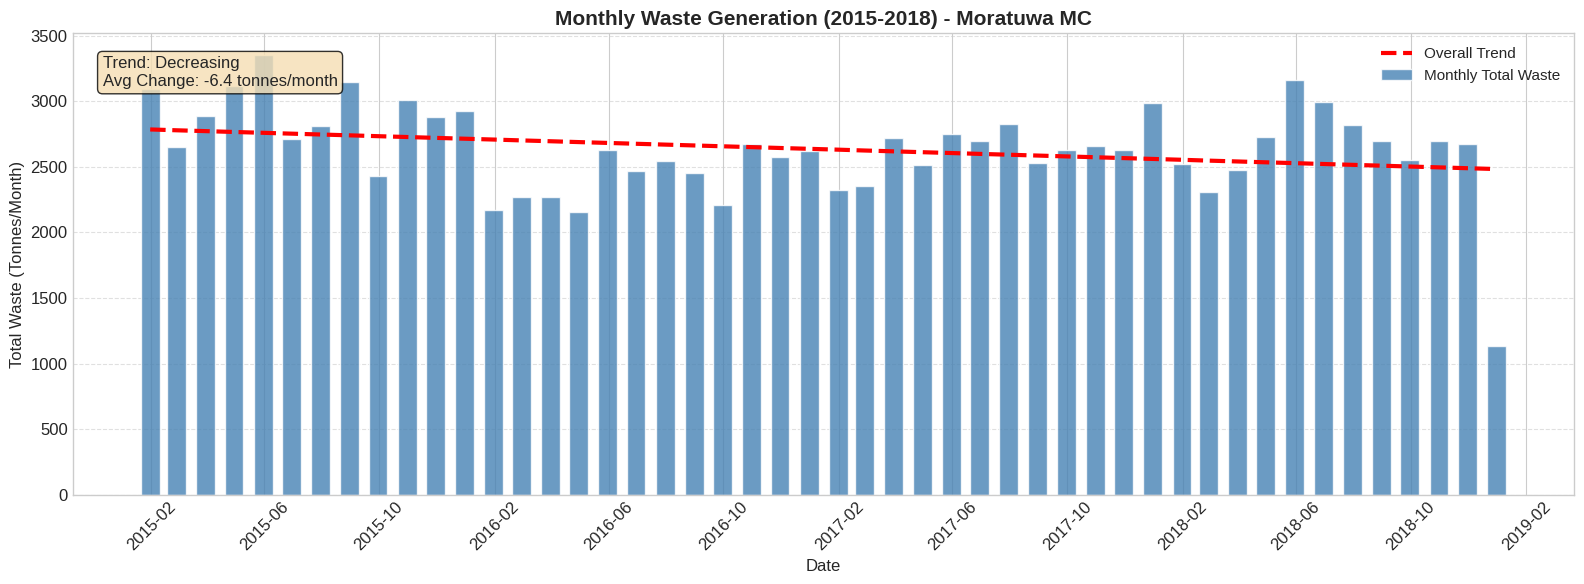

In [18]:
print("=" * 100)
print("VISUALIZING LONG-TERM TRENDS (Monthly Sums)")
print("=" * 100)


# --- Plot 431:  Monthly aggregation with linear trendline - Moratuwa MC ---
fig, ax = plt.subplots(figsize=(16, 6))

monthly_sum = daily.set_index('date').resample('M')['total_tonnes'].sum().reset_index()

ax.bar(monthly_sum['date'], monthly_sum['total_tonnes'], width=20,
       color='steelblue', edgecolor='white', alpha=0.8, label='Monthly Total Waste')

# fit linear trendline
x_numeric = np.arange(len(monthly_sum))
z = np.polyfit(x_numeric, monthly_sum['total_tonnes'].values, 1)
slope = z[0]
ax.plot(monthly_sum['date'], np.poly1d(z)(x_numeric), color='red',
        linestyle='--', linewidth=3, label='Overall Trend')

ax.set_title('Monthly Waste Generation (2015-2018) - Moratuwa MC', fontsize=15, fontweight='bold')
ax.set_ylabel('Total Waste (Tonnes/Month)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=45)

trend_direction = "Increasing" if slope > 0 else "Decreasing"
ax.text(0.02, 0.95,
        f'Trend: {trend_direction}\nAvg Change: {slope:.1f} tonnes/month',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, '431_monthly_trend_mo.png'), dpi=150, bbox_inches='tight')
plt.show()

VISUALIZING MACRO SEASONALITY (Day of Week)


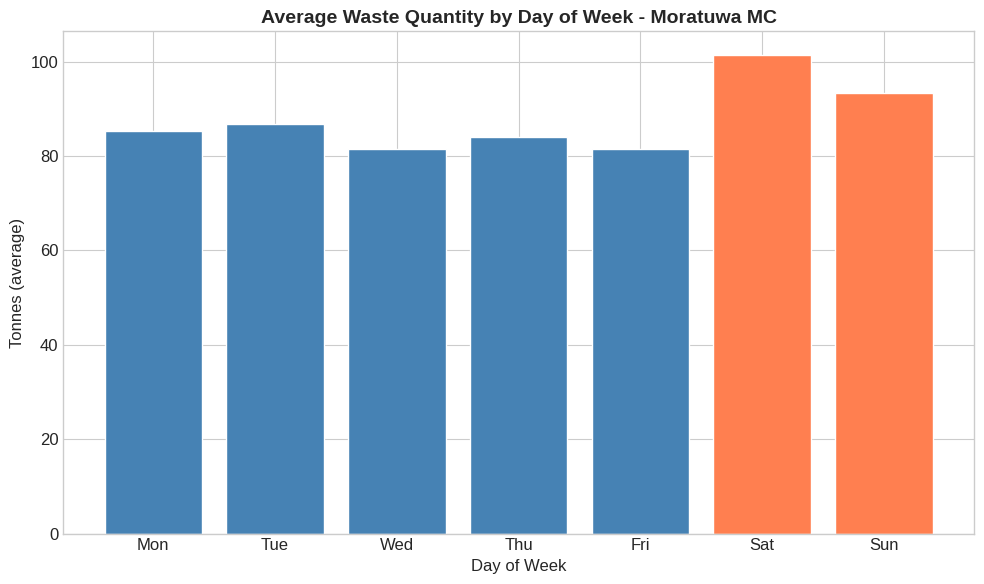

VISUALIZING MACRO SEASONALITY (Month)


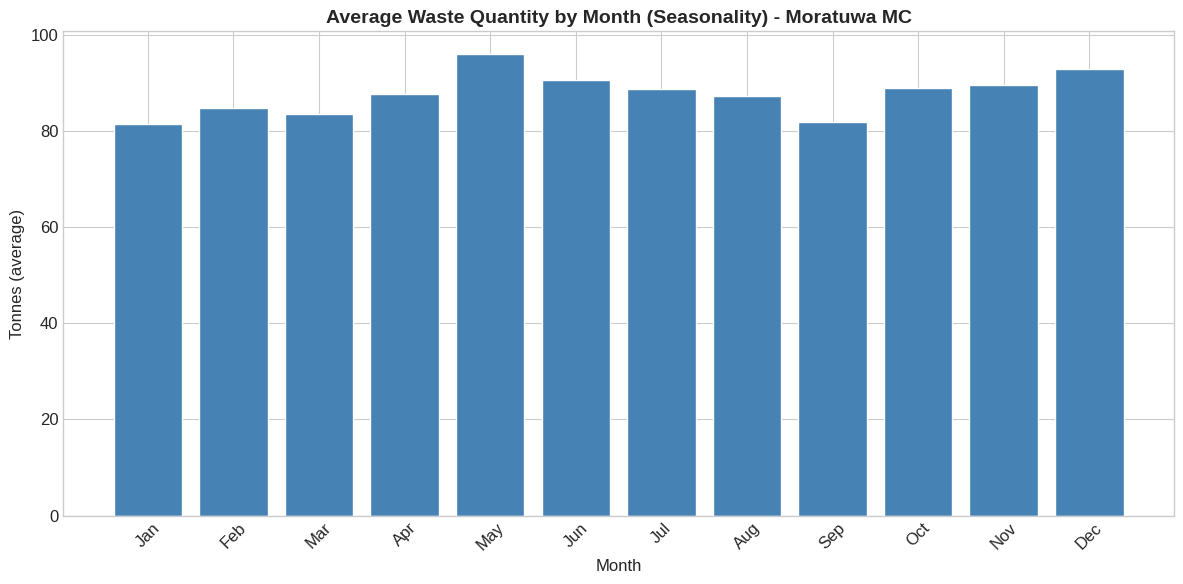

In [19]:
print("=" * 100)
print("VISUALIZING MACRO SEASONALITY (Day of Week)")
print("=" * 100)

# --- Plot 441: Average waste by day of week - Moratuwa MC ---
fig, ax = plt.subplots(figsize=(10, 6))

dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_data = daily.groupby('day_of_week')['total_tonnes'].mean()

ax.bar(range(7), dow_data.values, color=['steelblue']*5 + ['coral']*2, edgecolor='white')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_names)
ax.set_title('Average Waste Quantity by Day of Week - Moratuwa MC', fontsize=14, fontweight='bold')
ax.set_ylabel('Tonnes (average)')
ax.set_xlabel('Day of Week')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, '441_seasonality_dow_mo.png'), dpi=150, bbox_inches='tight')
plt.show()


print("=" * 100)
print("VISUALIZING MACRO SEASONALITY (Month)")
print("=" * 100)

# --- Plot 442: Average waste month - Moratuwa MC ---
fig, ax = plt.subplots(figsize=(12, 6))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_data = daily.groupby('month')['total_tonnes'].mean()

ax.bar(range(1, 13), month_data.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, rotation=45)
ax.set_title('Average Waste Quantity by Month (Seasonality) - Moratuwa MC', fontsize=14, fontweight='bold')
ax.set_ylabel('Tonnes (average)')
ax.set_xlabel('Month')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '442_seasonality_month_mo.png'), dpi=150, bbox_inches='tight')
plt.show()

VISUALIZING EFFECT OF WEEKENDS


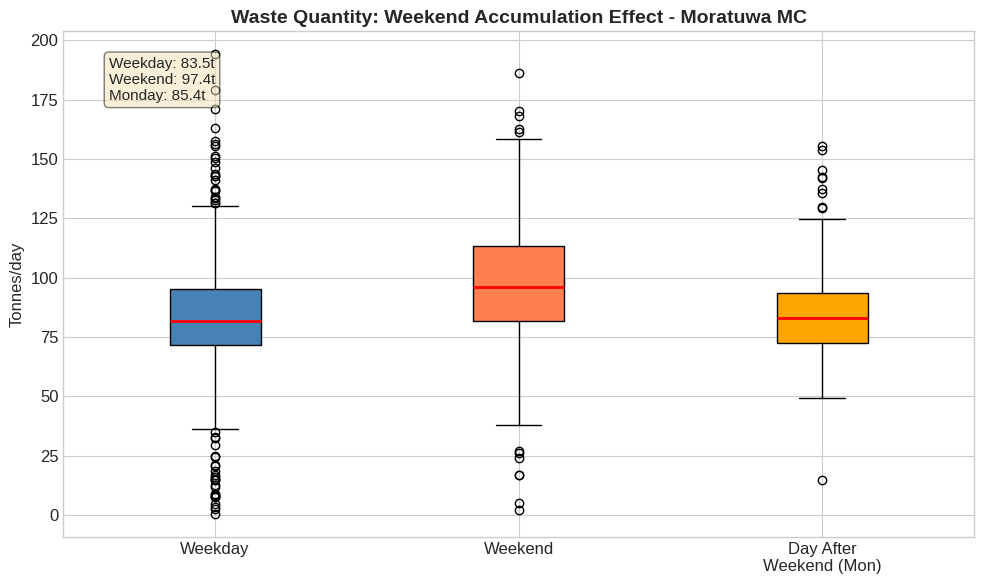

VISUALIZING EFFECT OF HOLIDAYS


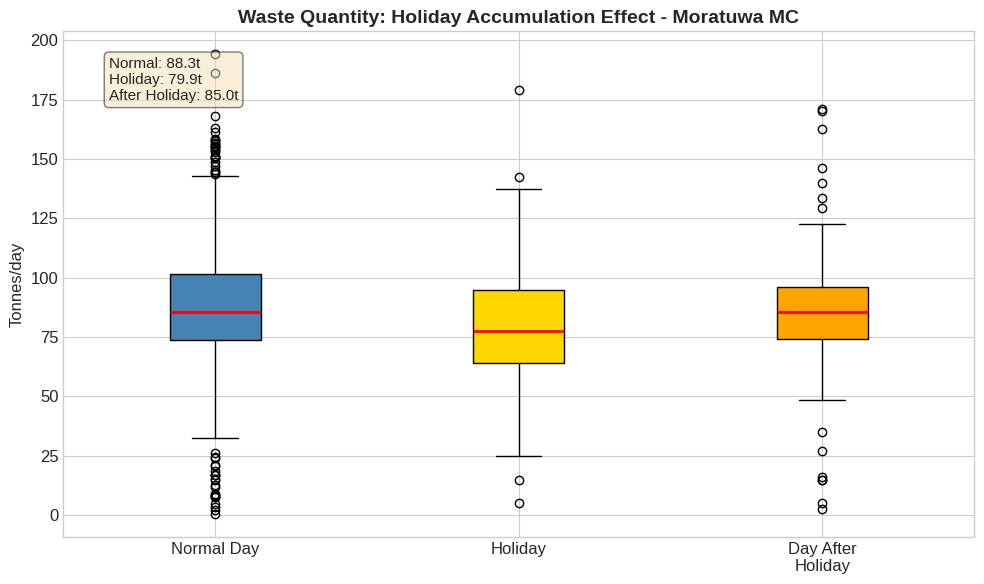

In [20]:
print("=" * 100)
print("VISUALIZING EFFECT OF WEEKENDS")
print("=" * 100)

# --- Plot 451: Weekend effect: Weekday vs Weekend boxplot - Moratuwa MC ---
fig, ax = plt.subplots(figsize=(10, 6))

weekend_data = [
    daily[(daily['is_weekend']==0) & (daily['is_after_weekend']==0)]['total_tonnes'].dropna(),
    daily[daily['is_weekend']==1]['total_tonnes'].dropna(),
    daily[daily['is_after_weekend']==1]['total_tonnes'].dropna()
]
bp = ax.boxplot(weekend_data, tick_labels=['Weekday', 'Weekend', 'Day After\nWeekend (Mon)'], patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
bp['boxes'][2].set_facecolor('orange')

ax.set_title('Waste Quantity: Weekend Accumulation Effect - Moratuwa MC', fontsize=14, fontweight='bold')
ax.set_ylabel('Tonnes/day')

wd_mean = weekend_data[0].mean()
we_mean = weekend_data[1].mean()
after_mean = weekend_data[2].mean()

ax.text(0.05, 0.95,
        f'Weekday: {wd_mean:.1f}t\nWeekend: {we_mean:.1f}t\nMonday: {after_mean:.1f}t',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '451_weekend_accumulation_effect_mo.png'), dpi=150, bbox_inches='tight')
plt.show()


print("=" * 100)
print("VISUALIZING EFFECT OF HOLIDAYS")
print("=" * 100)

# --- Plot 452: Holiday effect: Non-Holiday vs Holiday boxplot - Moratuwa MC ---
fig, ax = plt.subplots(figsize=(10, 6))

hol_data = [
    daily[(daily['is_holiday']==0) & (daily['is_after_holiday']==0)]['total_tonnes'].dropna(),
    daily[daily['is_holiday']==1]['total_tonnes'].dropna(),
    daily[daily['is_after_holiday']==1]['total_tonnes'].dropna()
]
bp = ax.boxplot(hol_data, tick_labels=['Normal Day', 'Holiday', 'Day After\nHoliday'], patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('gold')
bp['boxes'][2].set_facecolor('orange')

ax.set_title('Waste Quantity: Holiday Accumulation Effect - Moratuwa MC', fontsize=14, fontweight='bold')
ax.set_ylabel('Tonnes/day')

norm_mean = hol_data[0].mean()
hol_mean = hol_data[1].mean()
after_hol_mean = hol_data[2].mean()

ax.text(0.05, 0.95,
        f'Normal: {norm_mean:.1f}t\nHoliday: {hol_mean:.1f}t\nAfter Holiday: {after_hol_mean:.1f}t',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '452_holiday_accumulation_effect_mo.png'), dpi=150, bbox_inches='tight')
plt.show()

VISUALIZING OVERALL WEATHER EFFECTS (Bottom 25% vs Top 25%)


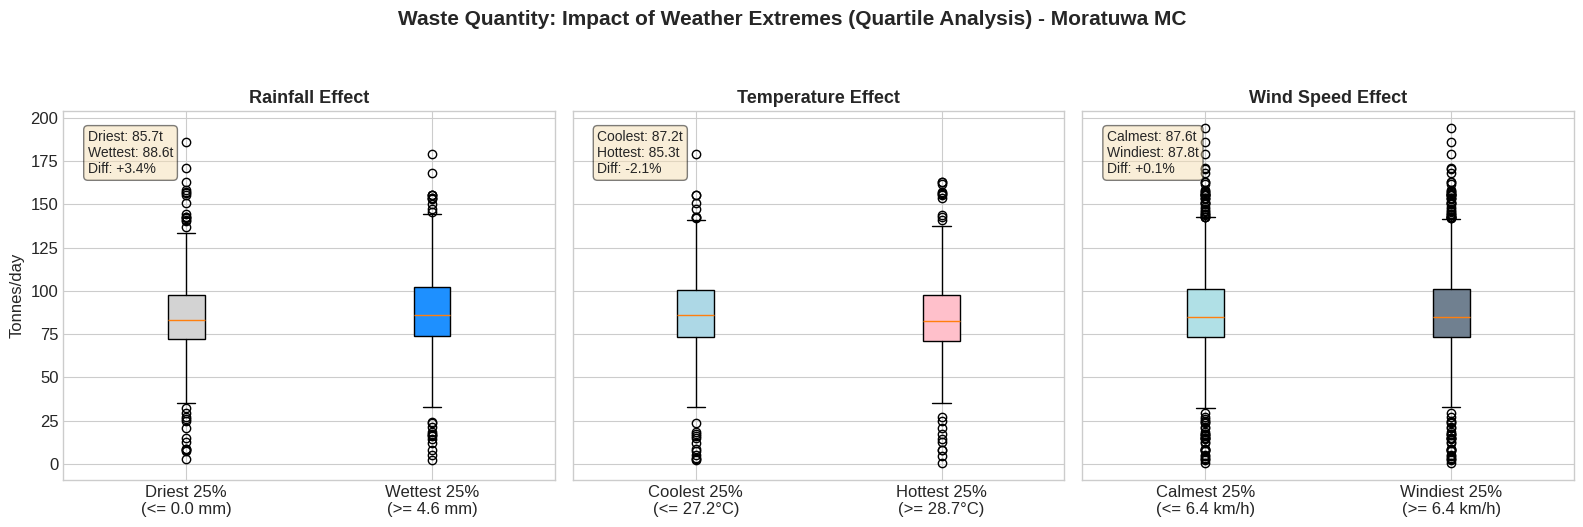

In [21]:
print("=" * 100)
print("VISUALIZING OVERALL WEATHER EFFECTS (Bottom 25% vs Top 25%)")
print("=" * 100)

# --- Plot 461: Weather impact: Quartile comparison for rain, temperature, wind - Moratuwa MC ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# rainfall effect
ax = axes[0]
prcp_q1, prcp_q3 = daily['prcp'].quantile(0.25), daily['prcp'].quantile(0.75)
driest = daily[daily['prcp'] <= prcp_q1]['total_tonnes'].dropna()
wettest = daily[daily['prcp'] >= prcp_q3]['total_tonnes'].dropna()

bp1 = ax.boxplot([driest, wettest],
                 tick_labels=[f'Driest 25%\n(<= {prcp_q1:.1f} mm)', f'Wettest 25%\n(>= {prcp_q3:.1f} mm)'],
                 patch_artist=True)
bp1['boxes'][0].set_facecolor('lightgray')
bp1['boxes'][1].set_facecolor('dodgerblue')
ax.set_title('Rainfall Effect', fontsize=13, fontweight='bold')
ax.set_ylabel('Tonnes/day')

prcp_diff = (wettest.mean() - driest.mean()) / driest.mean() * 100
ax.text(0.05, 0.95, f'Driest: {driest.mean():.1f}t\nWettest: {wettest.mean():.1f}t\nDiff: {"+" if prcp_diff>0 else ""}{prcp_diff:.1f}%',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


# temperature effect
ax = axes[1]
temp_q1, temp_q3 = daily['tavg'].quantile(0.25), daily['tavg'].quantile(0.75)
coldest = daily[daily['tavg'] <= temp_q1]['total_tonnes'].dropna()
hottest = daily[daily['tavg'] >= temp_q3]['total_tonnes'].dropna()

bp2 = ax.boxplot([coldest, hottest],
                 tick_labels=[f'Coolest 25%\n(<= {temp_q1:.1f}°C)', f'Hottest 25%\n(>= {temp_q3:.1f}°C)'],
                 patch_artist=True)
bp2['boxes'][0].set_facecolor('lightblue')
bp2['boxes'][1].set_facecolor('pink')
ax.set_title('Temperature Effect', fontsize=13, fontweight='bold')

temp_diff = (hottest.mean() - coldest.mean()) / coldest.mean() * 100
ax.text(0.05, 0.95, f'Coolest: {coldest.mean():.1f}t\nHottest: {hottest.mean():.1f}t\nDiff: {"+" if temp_diff>0 else ""}{temp_diff:.1f}%',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


# wind speed effect
ax = axes[2]
wind_q1, wind_q3 = daily['wspd'].quantile(0.25), daily['wspd'].quantile(0.75)
calmest = daily[daily['wspd'] <= wind_q1]['total_tonnes'].dropna()
windiest = daily[daily['wspd'] >= wind_q3]['total_tonnes'].dropna()

bp3 = ax.boxplot([calmest, windiest],
                 tick_labels=[f'Calmest 25%\n(<= {wind_q1:.1f} km/h)', f'Windiest 25%\n(>= {wind_q3:.1f} km/h)'],
                 patch_artist=True)
bp3['boxes'][0].set_facecolor('powderblue')
bp3['boxes'][1].set_facecolor('slategray')
ax.set_title('Wind Speed Effect', fontsize=13, fontweight='bold')

wind_diff = (windiest.mean() - calmest.mean()) / calmest.mean() * 100
ax.text(0.05, 0.95, f'Calmest: {calmest.mean():.1f}t\nWindiest: {windiest.mean():.1f}t\nDiff: {"+" if wind_diff>0 else ""}{wind_diff:.1f}%',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


plt.suptitle('Waste Quantity: Impact of Weather Extremes (Quartile Analysis) - Moratuwa MC',
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '461_weather_effect_mo.png'), dpi=150, bbox_inches='tight')
plt.show()

VISUALIZING CORRELATION HEATMAP


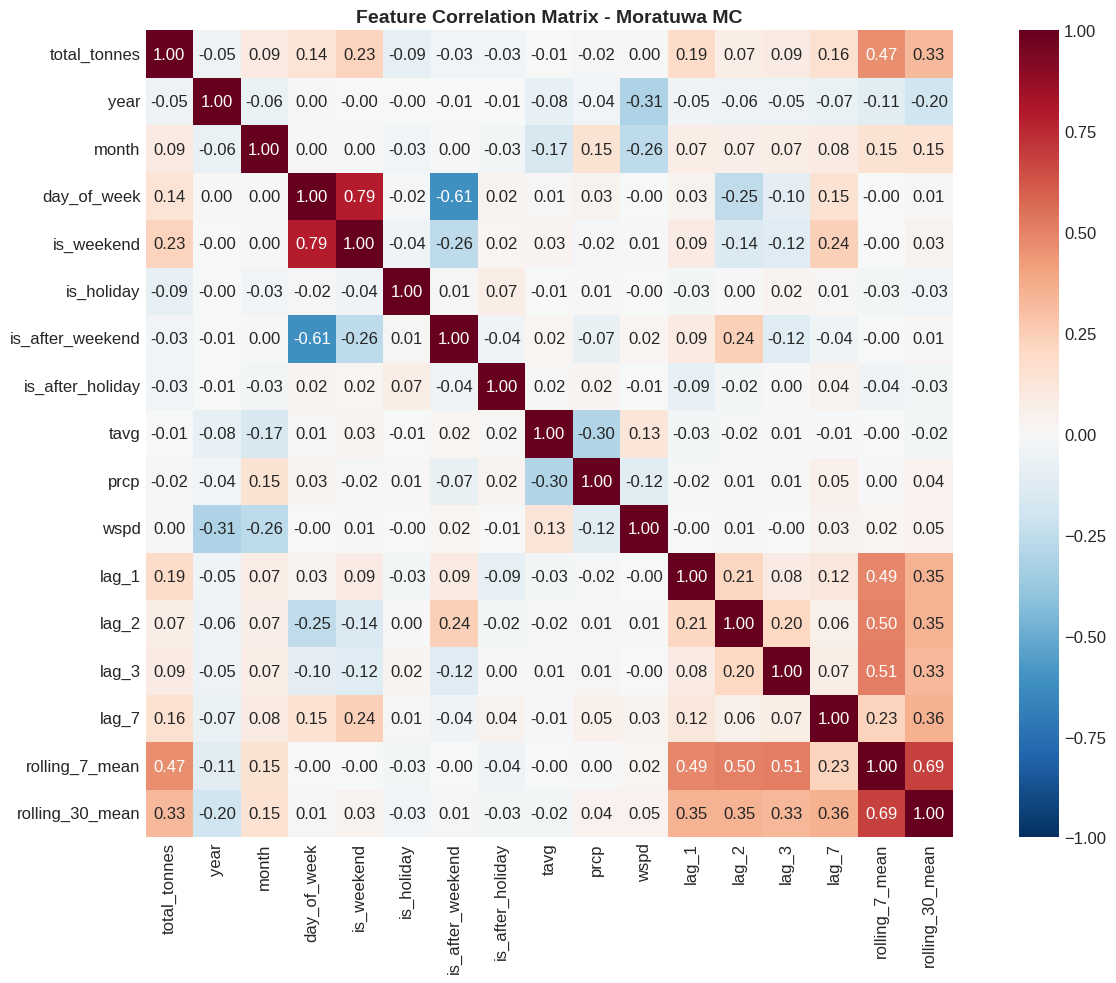

Strongest correlations with daily waste amount:
  rolling_7_mean       +0.465
  rolling_30_mean      +0.326
  is_weekend           +0.233
  lag_1                +0.190
  lag_7                +0.164
  day_of_week          +0.137
  is_holiday           -0.091
  month                +0.087
  lag_3                +0.085
  lag_2                +0.071
  year                 -0.054
  is_after_weekend     -0.033
  is_after_holiday     -0.032
  prcp                 -0.016
  tavg                 -0.006
  wspd                 +0.002


In [22]:
print("=" * 100)
print("VISUALIZING CORRELATION HEATMAP")
print("=" * 100)

# dropping first 30 rows where lag/rolling features are incomplete
daily_clean = daily.dropna().reset_index(drop=True)

# --- Plot 471: Correlation heatmap: feature vs target relationship - Moratuwa MC ---

corr_features = ['total_tonnes', 'year', 'month', 'day_of_week', 'is_weekend', 'is_holiday',
                 'is_after_weekend', 'is_after_holiday', 'tavg', 'prcp', 'wspd',
                 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'rolling_7_mean', 'rolling_30_mean']

corr_matrix = daily_clean[corr_features].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Feature Correlation Matrix - Moratuwa MC', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '471_correlation_heatmap_mo.png'), dpi=150, bbox_inches='tight')
plt.show()


# ranking
target_corr = corr_matrix['total_tonnes'].drop('total_tonnes').sort_values(key=abs, ascending=False)
print("Strongest correlations with daily waste amount:")
for feat, val in target_corr.items():
    print(f"  {feat:<20s} {val:+.3f}")

VISUALIZING AUTOCORRELATION ACF/PACF


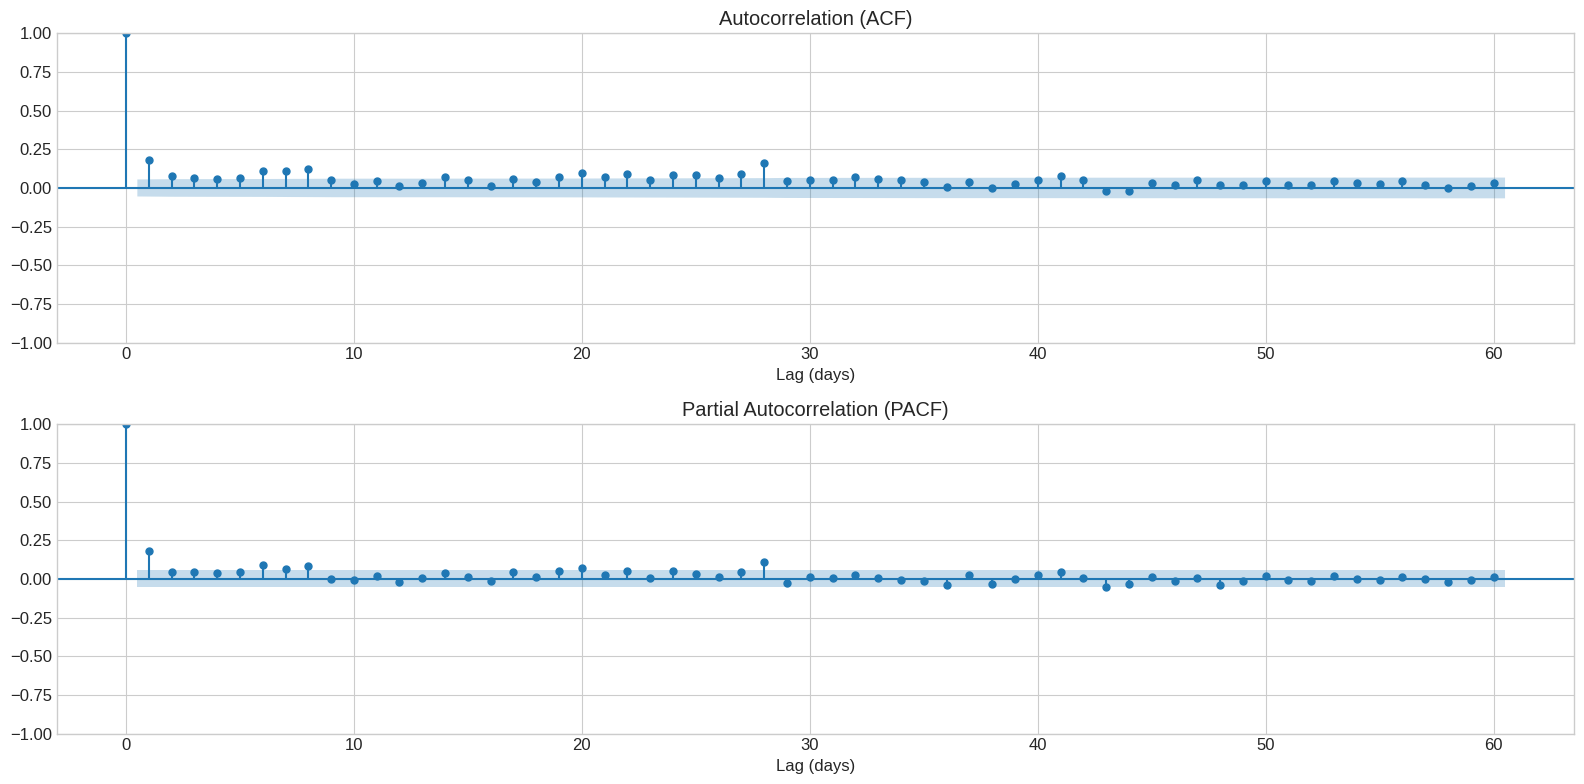

In [23]:
print("=" * 100)
print("VISUALIZING AUTOCORRELATION ACF/PACF")
print("=" * 100)

# --- Plot 472: Autocorrelation analysis (ACF/PACF) for SARIMA parameter selection - Moratuwa MC ---
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(daily_clean['total_tonnes'], lags=60, ax=axes[0], title='Autocorrelation (ACF)')
plot_pacf(daily_clean['total_tonnes'], lags=60, ax=axes[1], title='Partial Autocorrelation (PACF)')

axes[0].set_xlabel('Lag (days)')
axes[1].set_xlabel('Lag (days)')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '472_acf_pacf_mo.png'), dpi=150, bbox_inches='tight')
plt.show()

In [24]:
print("=" * 100)
print("STATIONARITY TEST (Augmented Dickey-Fuller)")
print("=" * 100)

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(daily_clean['total_tonnes'])

print("Augmented Dickey-Fuller Test:")
print(f"  Test Statistic:  {adf_result[0]:.4f}")
print(f"  P-Value:         {adf_result[1]:.6f}")
print(f"  Lags Used:       {adf_result[2]}")
print(f"  Observations:    {adf_result[3]}")
print(f"  Critical Values:")
for key, val in adf_result[4].items():
    print(f"    {key}: {val:.4f}")

if adf_result[1] < 0.05:
    print("\n  → Result: Series is STATIONARY (p < 0.05). No differencing needed.")
else:
    print("\n  → Result: Series is NON-STATIONARY (p >= 0.05). Differencing recommended for SARIMA.")

STATIONARITY TEST (Augmented Dickey-Fuller)
Augmented Dickey-Fuller Test:
  Test Statistic:  -8.8844
  P-Value:         0.000000
  Lags Used:       7
  Observations:    1258
  Critical Values:
    1%: -3.4356
    5%: -2.8638
    10%: -2.5680

  → Result: Series is STATIONARY (p < 0.05). No differencing needed.


# Processed Data saving

In [25]:
print("=" * 100)
print("FINAL DATASET CLEANUP & EXPORT")
print("=" * 100)

# dropping first 30 rows where lag/rolling features are incomplete
daily_clean = daily.dropna().reset_index(drop=True)

print(f"Total Rows Processed:      {daily.shape[0]}")
print(f"Rows with missing Lags:    {daily.shape[0] - daily_clean.shape[0]}")
print(f"Final ML-Ready Rows:       {daily_clean.shape[0]}")
print(f"Total Features Created:    {daily_clean.shape[1]}")

# export processed dataset
output_path = os.path.join(RES_DIR, 'moratuwa_processed.csv')
daily_clean.to_csv(output_path, index=False)

print("-" * 100)
print(f"SUCCESS: Processed dataset saved to:\n{output_path}")
print("-" * 100)

FINAL DATASET CLEANUP & EXPORT
Total Rows Processed:      1441
Rows with missing Lags:    175
Final ML-Ready Rows:       1266
Total Features Created:    30
----------------------------------------------------------------------------------------------------
SUCCESS: Processed dataset saved to:
/content/drive/MyDrive/DP/02_processed_data/moratuwa_processed.csv
----------------------------------------------------------------------------------------------------


# EDA Summary

In [26]:
print("\n" + "=" * 100)
print("FINAL DATA PIPELINE & EDA SUMMARY - Moratuwa MC")
print("=" * 100)

total_days = len(daily)
imputed_count = daily['is_imputed'].sum()
imputed_pct = (imputed_count / total_days) * 100

avg_temp = daily['tavg'].mean()
total_rainy_days = (daily['prcp'] > 0).sum()

# weekend acc stats
wd_mean = daily[(daily['is_weekend']==0) & (daily['is_after_weekend']==0)]['total_tonnes'].mean()
we_mean = daily[daily['is_weekend']==1]['total_tonnes'].mean()
mon_mean = daily[daily['is_after_weekend']==1]['total_tonnes'].mean()
we_diff_pct = (wd_mean - we_mean) / wd_mean * 100
mon_diff_pct = (mon_mean - wd_mean) / wd_mean * 100

# holiday acc stats
norm_mean = daily[(daily['is_holiday']==0) & (daily['is_after_holiday']==0)]['total_tonnes'].mean()
hol_mean = daily[daily['is_holiday']==1]['total_tonnes'].mean()
after_hol_mean = daily[daily['is_after_holiday']==1]['total_tonnes'].mean()
hol_diff_pct = (norm_mean - hol_mean) / norm_mean * 100
after_hol_diff_pct = (after_hol_mean - norm_mean) / norm_mean * 100

# top 5 corr
corr_features = ['total_tonnes', 'year', 'month', 'day_of_week', 'is_weekend', 'is_holiday',
                 'is_after_weekend', 'is_after_holiday', 'tavg', 'prcp', 'wspd',
                 'lag_1', 'lag_7', 'rolling_7_mean', 'rolling_30_mean']

target_corr = daily_clean[corr_features].corr()['total_tonnes'].drop('total_tonnes').sort_values(key=abs, ascending=False)
top5 = "\n".join([f"                         {feat:<20s} {val:+.3f}" for feat, val in target_corr.head(5).items()])

print(f"""
DATASET OVERVIEW:
  - Time Horizon:        2015-01-01 → 2018-12-31 ({total_days} days)
  - Raw Cleanup:         Removed outliers > 200t and 0t weight errors.
  - Smart Imputation:    {imputed_count} days ({imputed_pct:.1f}%) repaired using XGBoost Regressor.
  - Average Quantity:    {daily_clean['total_tonnes'].mean():.2f} tonnes/day
  - Median Quantity:     {daily_clean['total_tonnes'].median():.2f} tonnes/day

KEY INSIGHTS:
  - Weekend Effect:      {wd_mean:.1f}t (Weekdays) vs {we_mean:.1f}t (Weekends) → {abs(we_diff_pct):.1f}% {"drop" if we_diff_pct > 0 else "increase"}.
  - Monday Accumulation: {mon_mean:.1f}t (Mondays) vs {wd_mean:.1f}t (Other Weekdays) → {abs(mon_diff_pct):.1f}% {"increase" if mon_diff_pct > 0 else "drop"}.
  - Holiday Effect:      {norm_mean:.1f}t (Normal) vs {hol_mean:.1f}t (Holidays) → {abs(hol_diff_pct):.1f}% {"drop" if hol_diff_pct > 0 else "increase"}.
  - Post-Holiday Effect: {after_hol_mean:.1f}t (After Holiday) vs {norm_mean:.1f}t (Normal) → {abs(after_hol_diff_pct):.1f}% {"increase" if after_hol_diff_pct > 0 else "drop"}.
  - Weather Impact:      Quartile Analysis (Top 25% vs Bottom 25%) showed negligible variance (<5%)
                         for Temperature, Rain, and Wind Speed.
  - Growth Trend:        The overall trend shows an average change of {slope:.2f} tonnes per month.

AUTOCORRELATION ANALYSIS:
  - ACF suggest 7-day seasonal cycle (spikes at lags 7, 14, 21, 28...).
  - PACF confirms strongest direct dependencies at lags 1, 3, 5, 7 and 14.
  - Suggested SARIMA seasonal period: s=7 (weekly).

TOP FEATURE CORRELATIONS WITH TARGET:
{top5}

WEATHER INTEGRATION (Meteostat):
  - Avg Temperature:     {avg_temp:.1f}°C
  - Precipitation:       {total_rainy_days} rainy days identified in the 7-year period.

ENGINEERED FEATURES FOR MACHINE LEARNING ({daily_clean.shape[1]} columns):
  - Temporal:            Year, Month, Day_of_Week, Day_of_Year, Week_of_Year
  - Binary Flags:        is_weekend, is_holiday, is_after_weekend, is_after_holiday
  - Weather:             tavg, prcp, wspd
  - Lag Features:        lag_1, lag_2, lag_3, lag_7, lag_14, lag_30 (Past values)
  - Rolling Stats:       7-day and 30-day moving averages and standard deviations.
  - Cyclical Encoding:   Sine/Cosine transforms for Months and Days to capture time loops.

FINAL STATUS:            Dataset is gap-free, outlier-repaired, and ML-ready.
""")
print("=" * 100)


FINAL DATA PIPELINE & EDA SUMMARY - Moratuwa MC

DATASET OVERVIEW:
  - Time Horizon:        2015-01-01 → 2018-12-31 (1441 days)
  - Raw Cleanup:         Removed outliers > 200t and 0t weight errors.
  - Smart Imputation:    145 days (10.1%) repaired using XGBoost Regressor.
  - Average Quantity:    87.86 tonnes/day
  - Median Quantity:     85.29 tonnes/day

KEY INSIGHTS:
  - Weekend Effect:      83.5t (Weekdays) vs 97.4t (Weekends) → 16.6% increase.
  - Monday Accumulation: 85.4t (Mondays) vs 83.5t (Other Weekdays) → 2.3% increase.
  - Holiday Effect:      88.3t (Normal) vs 79.9t (Holidays) → 9.5% drop.
  - Post-Holiday Effect: 85.0t (After Holiday) vs 88.3t (Normal) → 3.8% drop.
  - Weather Impact:      Quartile Analysis (Top 25% vs Bottom 25%) showed negligible variance (<5%)
                         for Temperature, Rain, and Wind Speed.
  - Growth Trend:        The overall trend shows an average change of -6.43 tonnes per month.

AUTOCORRELATION ANALYSIS:
  - ACF suggest 7-day sea